# Clonal selection vs. adaptive compensation — main-text figure panels

Figure 1 produces the classic resistance pattern — growth, a sharp response to
therapy, then relapse back onto the original slope — from a single cell
population whose robust-perfect-adaptation (RPA) loop restores the drug target
$B$ to its setpoint. This notebook builds the panels for the figure that asks
what follows if the same curve is instead produced by **clonal selection**, with
no $A,B$ circuit at all: a drug-sensitive clone $C_s$ and a pre-existing
resistant clone $C_r$.

* **Panel A** — one curve, two mechanisms. The clonal model, fitted to Figure
  1's tumor curve, is indistinguishable from it; what differs is the state
  underneath — a composition that ratchets to 1 versus a target pulled back to
  its setpoint.
* **Panel B** — if resistance ratchets, maximum kill is the wrong objective:
  containment sustains a large sensitive population that suppresses $C_r$
  through competition.
* **Panel C** — the main text's two $A,B$-aware controllers, timescale
  separation and resonance, asked to maintain a burden rather than minimise it.
* **Panel D** — the measurement that tells the two apart: re-challenge after a
  drug holiday, which the RPA tumor responds to and the clonal one does not.

In [138]:
"""Clonal-selection resistance: two populations, no A/B circuit.

    dCs/dt = (r_s - kappa*u(t)) * Cs      drug-sensitive clone
    dCr/dt =  r_r              * Cr       drug-resistant clone (drug-blind)
    C      = Cs + Cr                      what the clinic measures

Closed form while the drug is a single step at t_rx:
    Cs(t) = Cs0 * exp(r_s*t - kappa*max(t - t_rx, 0)),   Cr(t) = Cr0 * exp(r_r*t),
so the net growth rate d(ln C)/dt is a weighted mean of the two clone rates and
relaxes to r_r no matter how large kappa is: the population "adapts" to the drug
by changing what it is made of. The Figure 1 RPA model is carried along as the
reference curve.
"""
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

PLOTS_DIR = Path("../plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a matplotlib figure to PLOTS_DIR as a PDF."""
    if not name.lower().endswith(".pdf"):
        name = f"{name}.pdf"
    save_path = PLOTS_DIR / name
    fig.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"Figure saved to {save_path}")


# --- clonal parameters ----------------------------------------------------
# r_s matches Figure 1's tumor growth rate c1; r_r is slightly lower (cost of
# resistance). kappa/f0 set how deep the response is and when relapse starts.
r_s, r_r = 1.0, 1.0         # growth rates of the sensitive / resistant clone
kappa, f0 = 3.4, 0.05         # kill rate at reference dose, initial resistant fraction
t_rx, e_ref = 2.0, 0.40       # treatment start (weeks); reference dose, as in Figure 1
T = 8.0                       # shared time axis, weeks
FS = 12                       # label / tick font size
DRUG_SHADE = "#d3f4fa"        # background for "drug on" / controller active

t = np.linspace(0, T, 1600)


def clones(t_eval, u=None, dose=1.0, r_s=r_s, r_r=r_r, kappa=kappa, f0=f0,
           C0=1.0, t_rx=t_rx):
    """Two competing clones, no A/B circuit:

        dCs/dt = (r_s - kappa*dose*u(t)) * Cs      drug-sensitive
        dCr/dt =  r_r                    * Cr      resistant, drug-blind

    u(t) is the drug, 1 while dosing. With u left at None it is the single step
    at t_rx used by panel A, for which the system is linear and decoupled, so the
    exact solution is

        Cs = C0*(1-f0)*exp(r_s*t - kappa*dose*max(t - t_rx, 0))
        Cr = C0*f0*exp(r_r*t)

    and that is what gets evaluated: it matches integrating the ODE to 1.6e-3
    (the solver's error at the switch) and is ~900x faster, which matters because
    panel A's fit calls this a few hundred times. Pass u for any other schedule
    (panel D's holiday and re-challenge) and it is integrated instead.
    """
    t_eval = np.asarray(t_eval, float)
    if u is None:
        on = np.maximum(t_eval - t_rx, 0.0)
        Cs = C0 * (1 - f0) * np.exp(r_s * t_eval - kappa * dose * on)
        Cr = C0 * f0 * np.exp(r_r * t_eval)
        return Cs, Cr

    f = lambda s_, y: [(r_s - kappa * dose * u(s_)) * y[0], r_r * y[1]]
    sol = solve_ivp(f, [t_eval[0], t_eval[-1]], [C0 * (1 - f0), C0 * f0],
                    max_step=0.005, dense_output=True).sol(t_eval)
    return sol[0], sol[1]


# --- Figure 1 RPA model, kept as the reference curve ----------------------
alpha, beta1, beta2, mu = 16.0, 1.0, 6.0, 1.0
c1, c2 = 1.0, 10.0


def rpa_traj(t_eval, u=lambda s: 1.0, dose=e_ref):
    """A, B, C of the Figure 1 model under drug schedule u(t) in {0, 1}."""
    def f(s, y):
        A, B, C = y
        return [alpha * (mu - B),
                beta1 * (1 - dose * u(s)) * A - beta2 * B,
                C * (c1 - c2 * max(mu - B, 0.0))]
    return solve_ivp(f, [t_eval[0], t_eval[-1]], [beta2 * mu / beta1, mu, 1.0],
                     max_step=0.005, dense_output=True).sol(t_eval)


step = lambda s: 1.0 if s >= t_rx else 0.0

C_rpa = rpa_traj(t, step)[2]                       # Figure 1C curve, the reference


def style(ax):
    ax.axvspan(t_rx, T, color=DRUG_SHADE, zorder=0)  # treatment window
    ax.set_xlim(0, T)
    ax.set_xticks(range(int(T) + 1))
    ax.set_xlabel('time (weeks)', fontsize=FS)
    ax.tick_params(labelsize=FS)
    ax.spines[['top', 'right']].set_visible(False)


## Main-text figure, panel A — one curve, two mechanisms

Three standalone figures on identical axes, one per mechanism. Each shows the
**same measurement** on top — the relapse curve, with the other mechanism's
curve dotted underneath so the superposition is visible — over the **state that
produced it**: the tumor's composition $f$, which ratchets irreversibly to 1,
versus the drug target $B$, which is pulled back to its setpoint and can be
pulled down again.

That contrast is what the rest of the figure runs on: a ratcheting state calls
for containment (panel B), a resetting state is what the timescale-separation
and resonance controllers exploit (panel C), and re-challenge after a holiday is
the measurement that tells you which one you have (panel D).

The third figure is the **hybrid** — the same $A,B$ circuit with a resistant
clone under selection, the mechanism panel C is run against. Fitted the same
way (with the resistant seed pinned at 5%, since a free seed would shrink to
zero and reproduce the RPA column exactly), it traces the same curve to 3.7% in
log space. It is the column where **both** states move: $B$ dips and is pulled
back to its setpoint while the composition ratchets from 5% to 34% resistant.

Figure saved to ../plots/figure_clonal_selection.pdf
Figure saved to ../plots/figure_adaptive_compensation.pdf
Figure saved to ../plots/figure_hybrid.pdf
clonal : f 0.079 -> 1.000 (ratchets), C(T)=247
RPA    : B/B0 min 0.709 -> 1.000 (setpoint), C(T)=245
fit: r_s=1.027 r_r=1.007 kappa=2.970 f0=0.0786, rms log-error vs the RPA curve = 0.0337
hybrid : f 0.050 -> 0.342 (ratchets) and B/B0 down to 0.709 then back (both states move), C(T)=231
  fitted with f0 pinned at 0.05: c2=11.69 (Figure 1 uses 10.00), r_r=0.921, rms log-error vs the RPA curve = 0.0365


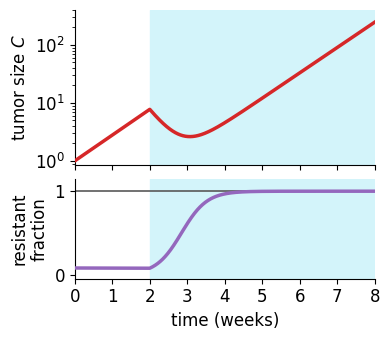

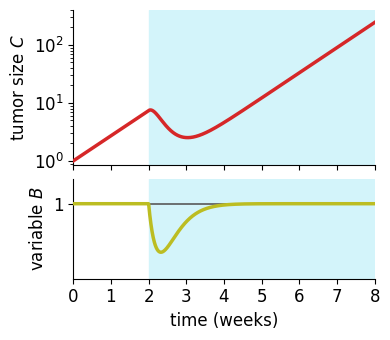

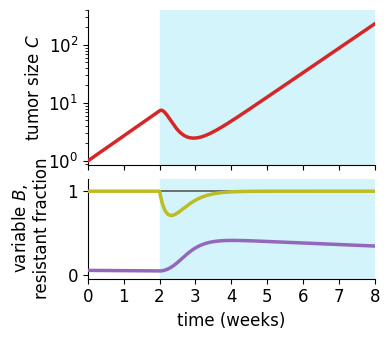

In [139]:
# --- Panel A: one curve, two mechanisms (one figure per mechanism) --------
# Two standalone figures, drawn on identical axes so they can sit side by side:
# the measured tumor curve on top -- with the *other* mechanism's curve dotted
# underneath, to show they superimpose -- and the state that produced it below.
# Clonal: a composition that ratchets to 1. RPA: a target pulled back to setpoint.
# The clonal parameters are fitted to Figure 1's tumor curve by least squares in
# log space, so "the same curve" is a fitted claim rather than an eyeballed one.
def unpack(p):
    """Unconstrained parameters -> (r_s, r_r, kappa, f0)."""
    return np.exp(p[0]), np.exp(p[1]), np.exp(p[2]), 1 / (1 + np.exp(-p[3]))


def loss(p):
    rs_, rr_, k_, f_ = unpack(p)
    Cs_, Cr_ = clones(t, r_s=rs_, r_r=rr_, kappa=k_, f0=f_)
    return np.mean((np.log(Cs_ + Cr_) - np.log(C_rpa)) ** 2)


p0 = np.array([np.log(r_s), np.log(r_r), np.log(kappa), np.log(f0 / (1 - f0))])
fit = minimize(loss, p0, method='Nelder-Mead',
               options={'maxiter': 4000, 'xatol': 1e-7, 'fatol': 1e-11})
r_s_fit, r_r_fit, kappa_fit, f0_fit = unpack(fit.x)

Cs_cl, Cr_cl = clones(t, r_s=r_s_fit, r_r=r_r_fit, kappa=kappa_fit, f0=f0_fit)
C_clonal = Cs_cl + Cr_cl
frac_cl = Cr_cl / C_clonal
A_rpa, B_rpa, C_rpa_ = rpa_traj(t, step)


# --- the hybrid: the same A,B circuit, plus a clone under selection -------
# Structure of abc_clonal_rhs (src/rpa_control/models.py) on Figure 1's A,B
# parameters, so all three columns share one circuit:
#     dA/dt  = alpha*(mu - B)
#     dB/dt  = beta1*(1 - e*u(t))*A - beta2*B
#     dCs/dt = Cs*(c1 - c2_h*max(mu - B, 0))     drug-sensitive clone
#     dCr/dt = r_r*Cr                            drug-blind (cr_sensitivity = 0)
# No carrying capacity here: the other two columns are competition-free over
# this window, and competition is panel B's subject.
f0_h = 0.05                    # resistant seed, pinned (see the fit below)


def hybrid_traj(t_eval, c2_h, r_r, f0=f0_h, u=step, dose=e_ref):
    """A, B, Cs, Cr of the hybrid under drug schedule u(t) in {0, 1}."""
    def f(s_, y):
        A, B, Cs, Cr = y
        kill = c2_h * max(mu - B, 0.0)
        return [alpha * (mu - B),
                beta1 * (1 - dose * u(s_)) * A - beta2 * B,
                Cs * (c1 - kill),
                r_r * Cr]
    return solve_ivp(f, [t_eval[0], t_eval[-1]],
                     [beta2 * mu / beta1, mu, 1 - f0, f0],
                     max_step=0.005, dense_output=True).sol(t_eval)


# Fitted like the clonal column -- least squares in log space against the same
# RPA curve -- but with f0 pinned: the clones never feed back into A, B, so Cs
# obeys the RPA tumor's own equation and C_hybrid = (1-f0)*C_rpa + f0*exp(r_r*t)
# exactly. Left free, f0 -> 0 would reproduce C_rpa and collapse this column
# into the middle one; pinning the seed makes the drug's kill strength carry
# the fit instead.
def loss_h(p):
    Ch = hybrid_traj(t, np.exp(p[0]), np.exp(p[1]))
    return np.mean((np.log(Ch[2] + Ch[3]) - np.log(C_rpa)) ** 2)


fit_h = minimize(loss_h, [np.log(c2), np.log(c1)], method='Nelder-Mead',
                 options={'maxiter': 800, 'xatol': 1e-6, 'fatol': 1e-12})
c2_h_fit, r_r_h_fit = np.exp(fit_h.x)

A_hyb, B_hyb, Cs_hyb, Cr_hyb = hybrid_traj(t, c2_h_fit, r_r_h_fit)
C_hybrid = Cs_hyb + Cr_hyb
frac_hyb = Cr_hyb / C_hybrid


def mechanism_panel(C_curve, C_other, state, color, ylabel, ylim, yticks, title, name,
                    state2=None, color2=None, labelpad=None):
    """Tumor curve (log) over the state variable behind it, as one figure."""
    fig, axes = plt.subplots(2, 1, figsize=(4.0, 3.5), sharex=True,
                             gridspec_kw={'height_ratios': [1.55, 1]})
    for ax in axes:
        style(ax)

    # axes[0].plot(t, C_other, color='0.55', lw=3.5, ls=':', zorder=2)  # other mechanism
    axes[0].plot(t, C_curve, color='tab:red', lw=2.5, zorder=3)
    axes[0].set_yscale('log')
    axes[0].set_ylim(0.85, 400)
    axes[0].set_ylabel('tumor size $C$', fontsize=FS)
    axes[0].set_xlabel('')
    # axes[0].set_title(title, fontsize=FS, pad=6)

    axes[1].plot(t, state, color=color, lw=2.5, zorder=3)
    if state2 is not None:                               # hybrid: both states
        axes[1].plot(t, state2, color=color2, lw=2.5, zorder=3)
    axes[1].axhline(1, color='0.35', lw=1.2, zorder=1)   # setpoint / full resistance
    axes[1].set_ylim(*ylim)
    axes[1].set_yticks(yticks)
    axes[1].set_ylabel(ylabel, fontsize=FS, labelpad=labelpad)

    fig.tight_layout(h_pad=0.4)
    save_fig(fig, name)
    return fig


fig_clonal = mechanism_panel(
    C_clonal, C_rpa_, frac_cl, 'tab:purple', 'resistant\nfraction',
    (-0.05, 1.15), [0, 1], 'clonal selection', "figure_clonal_selection")

fig_adaptive = mechanism_panel(
    C_rpa_, C_clonal, B_rpa / B_rpa[0], 'tab:olive', 'variable $B$',
    (0.55, 1.15), [1], 'adaptive compensation', "figure_adaptive_compensation")

fig_hybrid = mechanism_panel(
    C_hybrid, C_rpa_, B_hyb / B_hyb[0], 'tab:olive', 'variable $B$,\nresistant fraction',
    (-0.05, 1.15), [0, 1], 'hybrid', "figure_hybrid",
    state2=frac_hyb, color2='tab:purple', labelpad=12)   # clear of the panel above

print(f'clonal : f {frac_cl[0]:.3f} -> {frac_cl[-1]:.3f} (ratchets), C(T)={C_clonal[-1]:.0f}')
print(f'RPA    : B/B0 min {(B_rpa / B_rpa[0]).min():.3f} -> {(B_rpa / B_rpa[0])[-1]:.3f} '
      f'(setpoint), C(T)={C_rpa_[-1]:.0f}')
print(f'fit: r_s={r_s_fit:.3f} r_r={r_r_fit:.3f} kappa={kappa_fit:.3f} f0={f0_fit:.4f}, '
      f'rms log-error vs the RPA curve = '
      f'{np.sqrt(np.mean((np.log(C_clonal) - np.log(C_rpa)) ** 2)):.4f}')
print(f'hybrid : f {frac_hyb[0]:.3f} -> {frac_hyb[-1]:.3f} (ratchets) and B/B0 down to '
      f'{(B_hyb / B_hyb[0]).min():.3f} then back (both states move), C(T)={C_hybrid[-1]:.0f}')
print(f'  fitted with f0 pinned at {f0_h:.2f}: c2={c2_h_fit:.2f} (Figure 1 uses {c2:.2f}), '
      f'r_r={r_r_h_fit:.3f}, rms log-error vs the RPA curve = '
      f'{np.sqrt(np.mean((np.log(C_hybrid) - np.log(C_rpa)) ** 2)):.4f}')


In [140]:
# --- Model summary: equations and parameters actually in force ------------
# Printed after the fit, so the clonal column shows the values panel A used.
# Everything here is read back from the variables above -- nothing is retyped.
omega_n = np.sqrt(alpha * beta1 * (1 - e_ref))
zeta = beta2 / (2 * omega_n)
rms_log = np.sqrt(np.mean((np.log(C_clonal) - np.log(C_rpa)) ** 2))
max_resid = np.max(np.abs(C_clonal / C_rpa - 1))
rms_hyb = np.sqrt(np.mean((np.log(C_hybrid) - np.log(C_rpa)) ** 2))
max_resid_hyb = np.max(np.abs(C_hybrid / C_rpa - 1))

print(f"""
=====================================================================
 MODEL SUMMARY   RPA parameters are fixed inputs; the clonal and hybrid
                 ones are fitted to the RPA tumor curve (one direction only).
=====================================================================

ADAPTIVE COMPENSATION -- RPA circuit of Figure 1 (integrated, max_step=0.005)

    dA/dt = alpha * (mu - B)
    dB/dt = beta1 * (1 - e*u(t)) * A - beta2 * B
    dC/dt = C * (c1 - c2 * max(mu - B, 0))
    u(t)  = 1 for t >= t_rx, else 0
    y0    = [beta2*mu/beta1, mu, C0] = [{beta2 * mu / beta1:.2f}, {mu:.2f}, 1.00]

    alpha = {alpha:6.3f}    beta1 = {beta1:6.3f}    beta2 = {beta2:6.3f}    mu = {mu:5.3f}
    c1    = {c1:6.3f}    c2    = {c2:6.3f}    e     = {e_ref:6.3f}  (block of the A->B arm)

    derived: loop gain alpha*beta1*(1-e) = {alpha * beta1 * (1 - e_ref):.3f}
             omega_n = {omega_n:.3f},  zeta = {zeta:.3f}  ({'under' if zeta < 1 else 'over'}damped)
             drop rate at onset = -beta2*e = {-beta2 * e_ref:.3f} per week
             B: {B_rpa.min() / B_rpa[0]:.3f} at the nadir -> {B_rpa[-1] / B_rpa[0]:.3f} (setpoint restored)

CLONAL SELECTION -- two populations, no circuit

    dCs/dt = (r_s - kappa*u(t)) * Cs
    dCr/dt =  r_r               * Cr
    u(t)   = 1 for t >= t_rx, else 0   (the same drug schedule as above)
    y0     = [C0*(1-f0), C0*f0] = [{1 - f0_fit:.4f}, {f0_fit:.4f}]
    C      = Cs + Cr        f = Cr / C        (f is panel A's bottom row)

    linear and decoupled under that step, so it is evaluated in closed form
    rather than integrated (agrees to 1.6e-3, and the fit needs the speed):
        Cs(t) = C0*(1 - f0)*exp(r_s*t - kappa*max(t - t_rx, 0))
        Cr(t) = C0*f0*exp(r_r*t)

                      start (hand)      fitted (used in panel A)
    r_s               {r_s:12.4f}      {r_s_fit:12.4f}
    r_r               {r_r:12.4f}      {r_r_fit:12.4f}
    kappa             {kappa:12.4f}      {kappa_fit:12.4f}
    f0                {f0:12.4f}      {f0_fit:12.4f}

    fit: Nelder-Mead on mean((log C_clonal - log C_rpa)^2)
         rms log-error = {rms_log:.4f}   max |residual| = {100 * max_resid:.1f}% of the RPA curve
    f: {frac_cl[0]:.3f} -> {frac_cl[-1]:.3f}   (ratchets; the net growth rate relaxes to r_r)

HYBRID -- the same A,B circuit with a clone under selection (integrated)

    dA/dt  = alpha * (mu - B)                  (A, B exactly as above)
    dB/dt  = beta1 * (1 - e*u(t)) * A - beta2 * B
    dCs/dt = Cs * (c1 - c2_h*max(mu - B, 0))   drug-sensitive clone
    dCr/dt = r_r * Cr                          drug-blind, cr_sensitivity = 0
    y0     = [beta2*mu/beta1, mu, C0*(1 - f0), C0*f0]
    C      = Cs + Cr        f = Cr / C

    f0    = {f0_h:6.4f}   PINNED -- free, it would go to 0 and reproduce the RPA
                      curve exactly, collapsing this column into that one
    c2_h  = {c2_h_fit:6.3f}   fitted (Figure 1's own c2 = {c2:.3f})
    r_r   = {r_r_h_fit:6.3f}   fitted
    rms log-error = {rms_hyb:.4f}   max |residual| = {100 * max_resid_hyb:.1f}% of the RPA curve

    both states move: B/B0 dips to {B_hyb.min() / B_hyb[0]:.3f} and returns to the setpoint,
    while f ratchets {frac_hyb[0]:.3f} -> {frac_hyb[-1]:.3f}

SHARED
    t_rx = {t_rx:.1f} weeks (treatment starts)    T = {T:.1f} weeks, {len(t)} points
    C0   = 1.00                  C(T): clonal {C_clonal[-1]:.0f}, hybrid {C_hybrid[-1]:.0f}, RPA {C_rpa[-1]:.0f}
=====================================================================""")


 MODEL SUMMARY   RPA parameters are fixed inputs; the clonal and hybrid
                 ones are fitted to the RPA tumor curve (one direction only).

ADAPTIVE COMPENSATION -- RPA circuit of Figure 1 (integrated, max_step=0.005)

    dA/dt = alpha * (mu - B)
    dB/dt = beta1 * (1 - e*u(t)) * A - beta2 * B
    dC/dt = C * (c1 - c2 * max(mu - B, 0))
    u(t)  = 1 for t >= t_rx, else 0
    y0    = [beta2*mu/beta1, mu, C0] = [6.00, 1.00, 1.00]

    alpha = 16.000    beta1 =  1.000    beta2 =  6.000    mu = 1.000
    c1    =  1.000    c2    = 10.000    e     =  0.400  (block of the A->B arm)

    derived: loop gain alpha*beta1*(1-e) = 9.600
             omega_n = 3.098,  zeta = 0.968  (underdamped)
             drop rate at onset = -beta2*e = -2.400 per week
             B: 0.709 at the nadir -> 1.000 (setpoint restored)

CLONAL SELECTION -- two populations, no circuit

    dCs/dt = (r_s - kappa*u(t)) * Cs
    dCr/dt =  r_r               * Cr
    u(t)   = 1 for t >= t_rx, else 0   (the sa

## Main-text figure, panel B — containment restrains the resistant clone

If resistance is a composition that ratchets (panel A), killing as hard as
possible is the wrong objective: it clears the sensitive clone, **releases the
resistant one from competition**, and hands it the whole carrying capacity. The
panels above have no competition in them at all — two uncoupled exponentials —
so this panel adds the shared carrying capacity that makes containment possible:

$$\dot C_s = r_s C_s\Bigl(1 - \frac{C}{K}\Bigr) - u(t)\,\kappa\,C_s, \qquad
  \dot C_r = r_r C_r\Bigl(1 - \frac{C}{K}\Bigr).$$

Two figures on identical axes, one per schedule. **Maximum dose** holds the drug
on throughout. **Adaptive therapy** withdraws it once burden falls to 70% of the
starting size and re-treats when it returns to 100% — deliberately *sustaining* a
large tumor, most of it still drug-sensitive, to keep $C_r$ competitively
suppressed. The schedule is not fixed in advance; it is run by the project's
burden-threshold controller, `simulation.simulate_threshold_driven`, so the
cycles are whatever the dynamics produce.

Shading marks drug-on — the whole window in one figure, a third of it in the
other.

Figure saved to ../plots/figure_maxdose_therapy.pdf
Figure saved to ../plots/figure_adaptive_therapy.pdf
maximum dose   : burden 0.07-1.39x baseline, duty 1.00, resistant fraction 1.00 at 200 wk, progression 181 wk
adaptive therapy: burden 0.50-1.00x baseline, duty 0.32, resistant fraction 0.60 at 200 wk, progression never


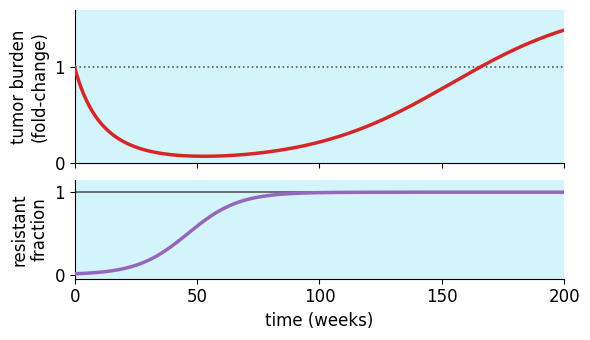

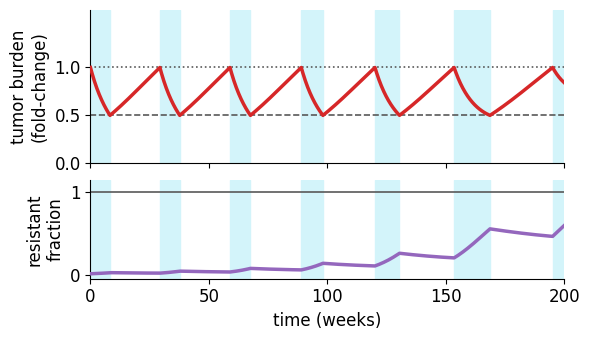

In [141]:
# --- Panel B: adaptive therapy restrains resistance through competition ----
# Competition is what does the restraining, so this panel needs the logistic
# two-clone model (the panels above are competition-free exponentials):
#     dCs/dt = r_s*Cs*(1 - C/K) - u(t)*kappa*Cs,    dCr/dt = r_r*Cr*(1 - C/K)
# Maximum dose empties the tumor, releases Cr from competition and hands it the
# whole carrying capacity. Adaptive therapy withdraws the drug at 70% of the
# starting burden and re-treats at 100%, sustaining a large sensitive population
# that keeps Cr suppressed. The schedule is run by the project's existing
# burden-threshold controller, simulation.simulate_threshold_driven.
from rpa_control import simulation

K_B, r_s_B, r_r_B = 1.0, 0.06, 0.035    # carrying capacity; clone growth rates (per week)
kappa_B, f0_B = 0.12, 0.01              # kill rate while dosing; initial resistant fraction
base_B, T_B = 0.60, 200.0               # starting burden (fraction of K); horizon (weeks)
off_frac, on_frac = 0.5, 1.0            # withdraw at 70% of baseline, re-treat at 100%
prog_mult = 1.2                         # progression = 1.2x the starting burden


class ClonalCompetition:
    """Two clones sharing one carrying capacity; the drug kills only Cs."""
    state_vars = ['Cs', 'Cr']

    def __init__(self, r_s, r_r, K):
        self.r_s, self.r_r, self.K = r_s, r_r, K

    def get_f(self, overrides=None):
        kill = overrides.get('kill', 0.0) if overrides else 0.0

        def f(t, y):
            Cs, Cr = y
            growth = 1 - (Cs + Cr) / self.K
            return [self.r_s * Cs * growth - kill * Cs, self.r_r * Cr * growth]
        return f


def time_to_progression(t_, total, baseline, multiple=prog_mult, after=0.0):
    """First time total crosses multiple x baseline, searching after `after`."""
    hit = (total >= multiple * baseline) & (t_ > after)
    return float(t_[np.argmax(hit)]) if hit.any() else None


model_B = ClonalCompetition(r_s_B, r_r_B, K_B)
y0_B = np.array([base_B * (1 - f0_B), base_B * f0_B])
burden_fn = lambda y: y[0] + y[1]

# maximum dose: drug on for the whole horizon
t_mtd = np.linspace(0, T_B, 4000)
y_mtd = solve_ivp(model_B.get_f({'kill': kappa_B}), [0, T_B], y0_B,
                  max_step=0.5, dense_output=True).sol(t_mtd)

# adaptive therapy: the controller decides its own on/off intervals
t_adapt, y_adapt, on_adapt = simulation.simulate_threshold_driven(
    model_B, 'kill', kappa_B, 0.0, burden_fn, off_frac=off_frac, on_frac=on_frac,
    T_horizon=T_B, y0=y0_B)


def therapy_panel(t_, y_, on_ranges, title, name):
    """Tumor burden on top, the resistant fraction it leaves behind below."""
    total = y_[0] + y_[1]
    fig, axes = plt.subplots(2, 1, figsize=(6.0, 3.5), sharex=True,
                             gridspec_kw={'height_ratios': [1.55, 1]})
    for ax in axes:
        for a, b in on_ranges:                          # drug on
            ax.axvspan(a, min(b, T_B), color=DRUG_SHADE, zorder=0)
        ax.set_xlim(0, T_B)
        ax.set_xticks(range(0, int(T_B) + 1, 50))
        ax.tick_params(labelsize=FS)
        ax.spines[['top', 'right']].set_visible(False)

    axes[0].axhline(1, color='0.35', lw=1.2, ls=':', zorder=1)           # starting burden
    if name == "figure_adaptive_therapy":
        axes[0].axhline(off_frac, color='0.35', lw=1.2, ls='--', zorder=1)   # withdrawal level
    
    axes[0].plot(t_, total / base_B, color='tab:red', lw=2.5, zorder=3)
    axes[0].set_ylim(0, 1.6)
    axes[0].set_yticks([0, 1])
    if name == "figure_adaptive_therapy":
        axes[0].set_yticks([0, off_frac, 1])
    axes[0].set_ylabel('tumor burden\n(fold-change)', fontsize=FS)
    # axes[0].set_title(title, fontsize=FS, pad=6)

    axes[1].plot(t_, y_[1] / total, color='tab:purple', lw=2.5, zorder=3)
    axes[1].axhline(1, color='0.35', lw=1.2, zorder=1)                   # fully resistant
    axes[1].set_ylim(-0.05, 1.15)
    axes[1].set_yticks([0, 1])
    axes[1].set_ylabel('resistant\nfraction', fontsize=FS)
    axes[1].set_xlabel('time (weeks)', fontsize=FS)

    fig.tight_layout(h_pad=0.4)
    save_fig(fig, name)
    return fig


fig_mtd = therapy_panel(t_mtd, y_mtd, [(0.0, T_B)], 'maximum dose',
                        "figure_maxdose_therapy")
fig_adapt = therapy_panel(t_adapt, y_adapt, on_adapt, 'adaptive therapy',
                          "figure_adaptive_therapy")

for label, t_, y_, on_ranges in [('maximum dose   ', t_mtd, y_mtd, [(0.0, T_B)]),
                                 ('adaptive therapy', t_adapt, y_adapt, on_adapt)]:
    total = y_[0] + y_[1]
    nadir_t = t_[total.argmin()]
    ttp = time_to_progression(t_, total, base_B, after=nadir_t)
    duty = sum(min(b, T_B) - a for a, b in on_ranges) / T_B
    print(f'{label}: burden {total.min() / base_B:.2f}-{total.max() / base_B:.2f}x baseline, '
          f'duty {duty:.2f}, resistant fraction {y_[1][-1] / total[-1]:.2f} at {T_B:.0f} wk, '
          f'progression {"never" if ttp is None else f"{ttp:.0f} wk"}')

## Main-text figure, panel C — the AB-aware controllers, asked to contain

Panel B's containment came from a burden-threshold rule that knows nothing about
the circuit. The main text's two controllers act on the $A,B$ loop itself, and
both retune to the same objective — **hold the burden at 80% of its starting
size** instead of driving it to zero — against the same two-clone tumor
(`ABCClonalModel`, fully resistant clone, rare pre-existing seed).

* **Timescale-separation therapy** pulses $b_1$, measuring its own half-durations
  from the dynamics: treat until burden reaches the target, release until it
  returns to baseline, then freeze both and repeat. It runs at a 13% duty cycle.
* **Resonance therapy** switches the spring constant $\alpha$ of the loop to pump
  $B$ into swings that kill on every excursion below $\mu$. Halting that pump
  outright overshoots badly (down to 0.4× and back up past 1.8×, the behaviour in
  `SI_clonal_selection_adaptive.ipynb`), so here the pump's **amplitude cap is
  scaled by how far burden sits above the target** — a proportional gate. The
  swings fade as the tumor approaches the target instead of blowing through it.

Both hold a large, mostly drug-sensitive tumor with the resistant fraction still
near 2% at the end of the horizon. The difference is in how the drug is spent:
TST pulses rarely and hard (shaded blocks), resonance stays engaged throughout
and modulates its amplitude (shaded throughout, like continuous dosing).

Figure saved to ../plots/figure_tst_therapy.pdf
Figure saved to ../plots/figure_resonance_therapy.pdf
TST schedule: T_on=9.67 (net-decay optimum), T_off=10.00, 6 on-phases; net log-decay per cycle = 0.249
  reaches the 50% target after 2.1 cycles
TST      : burden 0.50-1.00x baseline, duty 0.22, resistant fraction 0.004 at t=200, B in [0.59, 1.68]
resonance: burden 0.48-1.05x baseline, duty 0.43, resistant fraction 0.006 at t=200, B in [-0.87, 2.83]


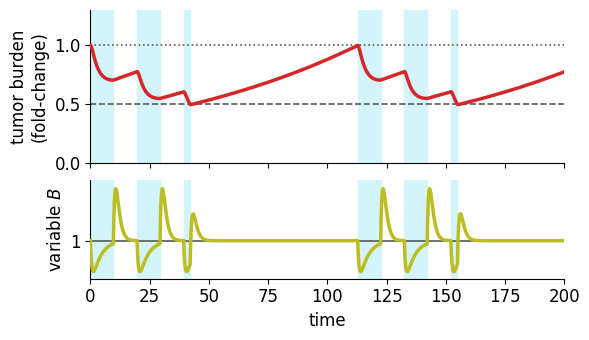

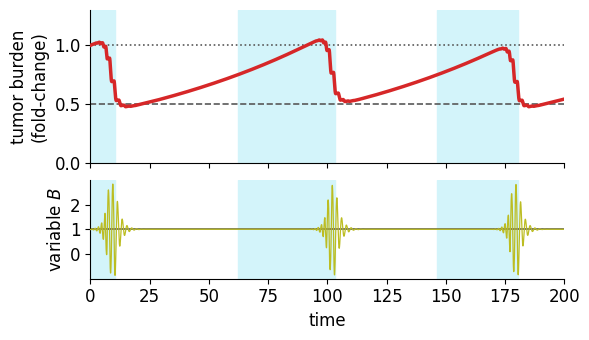

In [142]:
# --- Panel C: the AB-aware controllers, asked to maintain a burden -------
# Both strategies from the main text, run against the same two-clone tumor with
# the parameters of SI_clonal_selection_adaptive.ipynb. Timescale-separation
# (TST) pulses b1, measuring its own on/off durations from the dynamics: treat
# until burden reaches the target, release until it returns to baseline, then
# freeze both. Resonance therapy instead switches the spring constant alpha of
# the A,B loop to pump B into bounded swings that kill on every excursion below
# mu, and gates that pump on burden -- halt at 60% of baseline, restart at 70%.
from rpa_control import simulation
from rpa_control.models import ABCClonalModel, a1, b1, b1_on, b2, A_ss, B_ss

# k_C scales the tumor's own timescale against the fast A,B loop: kill strength
# and both growth rates together, as in the edge case of
# SI_strategies_with_clonal_selection.ipynb. Scaling c2 and r_s by the same
# factor leaves TST's optimal on-duration unchanged -- it is set by the A,B
# kinetics alone -- but shrinks the decay each cycle delivers, so the schedule
# walks the burden down over several cycles instead of reaching the target in one.
k_C = 0.2                                # tumor timescale relative to the A,B loop
r_s_C, r_r_C = k_C * 0.05, k_C * 0.03    # clone growth rates
c2_C, K_C = k_C * 1.2, 1000.0            # kill strength per unit deficit; capacity
Cs0_C, Cr0_C = 10.0, 0.01                # rare pre-existing resistant seed
mu_C = 1.0                               # B setpoint
T_off_C = 10.0                           # off-duration cap between cycles
restart_C = 1.00                         # re-treat once burden regrows to baseline
hold_C, T_C = 0.50, 200.0                # TST containment target (fold-change); horizon
off_frac_res, on_frac_res = 0.6, 0.75     # resonance gate: halt at 60%, restart at 70%

model_C = ABCClonalModel(r_s=r_s_C, r_r=r_r_C, carrying_capacity=K_C,
                         cr_sensitivity=0.0, c2=c2_C)
y0_C = np.array([A_ss, B_ss, Cs0_C, Cr0_C])
base_C = Cs0_C + Cr0_C
burden_C = lambda y: y[2] + y[3]


# TST's on-duration comes from the fast A,B kinetics, not from a burden target:
# it maximises the net log-decay per cycle, c2*g(T_on) - r_s*(T_on + T_off),
# whose argmax is independent of the tumor's own rates. Cs decays as a sum of
# the two A,B modes lam1, lam2 while the drug is on, giving g in closed form.
disc_C = b2 ** 2 - 4 * a1 * b1_on
lam1_C = (-b2 + np.sqrt(disc_C)) / 2
lam2_C = (-b2 - np.sqrt(disc_C)) / 2
K1_C = b2 * mu_C * (b1_on / b1 - 1) / (lam1_C - lam2_C)


def decay_analytic(T_on, c2=c2_C):
    """Cumulative log-decay of Cs over one on-phase of length T_on."""
    T_on = np.asarray(T_on, float)
    return -c2 * K1_C * (np.exp(lam1_C * T_on) / lam1_C - np.exp(lam2_C * T_on) / lam2_C
                         - 1 / lam1_C + 1 / lam2_C)


_T_on_grid = np.linspace(0.01, 40, 4000)
_net = decay_analytic(_T_on_grid) - r_s_C * (_T_on_grid + T_off_C)
T_on_C = float(_T_on_grid[np.argmax(_net)])     # net-decay-optimal on-duration
net_per_cycle_C = float(_net.max())             # log-decay each cycle delivers


def run_tst_cycles(model, y0, T_on, T_off, low, high, T_total, base, dt=0.02):
    """Periodic TST -- T_on on, T_off off, both fixed in advance by the A,B
    kinetics -- with two burden thresholds layered on top:

      * an on-phase is cut short the moment the burden reaches low*base, and
        treatment then stops altogether (no further cycles);
      * treatment restarts only once the tumor has regrown to high*base, at
        which point the fixed cycle resumes from the start.

    The off-phase inside a cycle always runs its full T_off: the cycle is set by
    the fast A,B kinetics, not by the tumor's own state. The thresholds decide
    whether cycling happens at all, never how long a cycle lasts.
    """
    f_on, f_off = model.get_f({'b1': b1_on}), model.get_f({'b1': b1})

    def hit_low(t, y):
        return (y[2] + y[3]) - low * base
    hit_low.terminal, hit_low.direction = True, -1

    def hit_high(t, y):
        return (y[2] + y[3]) - high * base
    hit_high.terminal, hit_high.direction = True, 1

    ts, ys, on_ranges = [], [], []
    y, t0 = np.asarray(y0, float), 0.0
    treating = (y[2] + y[3]) > low * base

    def advance(f, span, event):
        """Integrate f for at most `span`, stopping early if `event` fires."""
        nonlocal y, t0
        sol = solve_ivp(f, (0, span), y, events=event, method='Radau',
                        dense_output=True, rtol=1e-8, atol=1e-10, max_step=0.5)
        used = float(sol.t[-1])
        tt = np.linspace(0, used, max(int(used / dt), 2))
        ts.append(tt + t0)
        ys.append(sol.sol(tt))
        y, t0 = sol.y[:, -1], t0 + used
        return used, bool(event is not None and sol.t_events[0].size)

    while t0 < T_total - 1e-9:
        if treating:
            used, reached_target = advance(f_on, min(T_on, T_total - t0), hit_low)
            on_ranges.append((t0 - used, t0))
            if reached_target:            # target met: stop dosing and let it recover
                treating = False
                continue
            advance(f_off, min(T_off, T_total - t0), None)   # fixed off-phase
        else:
            _, recovered = advance(f_off, T_total - t0, hit_high)
            treating = recovered          # back at the upper threshold: cycle again
    return np.concatenate(ts), np.concatenate(ys, axis=1), on_ranges


t_tst, y_tst, on_tst = run_tst_cycles(model_C, y0_C, T_on_C, T_off_C,
                                      hold_C, restart_C, T_C, base_C)


# Resonance: parametric alpha-switching, amplitude-capped, gated on tumor burden
# (halt the pump at 60% of baseline, restart it at 70%) -- the strategy and the
# parameters of SI_clonal_selection_adaptive.ipynb.
def adaptive_alpha(B, Bdot, a_hard, a_soft, eq=mu_C):
    """Hard spring while B returns toward the setpoint, soft while it departs."""
    if B > eq:
        return a_hard if Bdot < 0 else a_soft
    return a_hard if Bdot > 0 else a_soft


def resonance_rhs(y, alpha, beta1, beta2, r_s, r_r, K, c2, cr_sens):
    """A,B homeostatic loop (spring constant alpha*beta1) driving the two clones."""
    A, B, Cs, Cr = y
    kill = c2 * max(mu_C - B, 0.0)
    gf = 1.0 - (Cs + Cr) / K
    return np.array([alpha * (mu_C - B),
                     beta1 * A - beta2 * B,
                     r_s * Cs * gf - kill * Cs,
                     r_r * Cr * gf - cr_sens * kill * Cr])


def simulate_resonance_gated(y0, T=T_C, dt=0.005, beta1=1.0, beta2=1.0,
                             a_hard=50.0, a_soft=10.0, alpha_off=10.0, amp_cap=1.0,
                             r_s=r_s_C, r_r=r_r_C, K=K_C, c2=c2_C, cr_sens=0.0,
                             off_frac=off_frac_res, on_frac=on_frac_res):
    """Fixed-step RK4. The capped alpha-pump runs while treating; halt (hold
    alpha_off) once burden <= off_frac x baseline, restart once it regrows to
    on_frac x baseline. The amplitude cap keeps the pump bounded and physical --
    without it the parametric pump diverges. Returns t, y, the resonance-active
    intervals and the baseline."""
    y0 = np.asarray(y0, float)
    baseline = y0[2] + y0[3]
    n = int(round(T / dt))
    t_ = np.linspace(0, T, n + 1)
    y = np.zeros((n + 1, 4))
    y[0] = y0
    treating_mask = np.zeros(n + 1, dtype=bool)
    treating = True
    for i in range(n):
        A, B, Cs, Cr = y[i]
        burden = Cs + Cr
        if treating and burden <= off_frac * baseline:
            treating = False
        elif (not treating) and burden >= on_frac * baseline:
            treating = True
        treating_mask[i] = treating
        Bdot = beta1 * A - beta2 * B
        alpha_i = (adaptive_alpha(B, Bdot, a_hard, a_soft)
                   if treating and abs(B - mu_C) < amp_cap else alpha_off)
        g = lambda z: resonance_rhs(z, alpha_i, beta1, beta2, r_s, r_r, K, c2, cr_sens)
        k1 = g(y[i]); k2 = g(y[i] + 0.5 * dt * k1)
        k3 = g(y[i] + 0.5 * dt * k2); k4 = g(y[i] + dt * k3)
        y[i + 1] = y[i] + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    treating_mask[-1] = treating_mask[-2]

    flips = np.where(np.diff(treating_mask.astype(int)) != 0)[0]
    edges = np.concatenate([[0], flips + 1, [n]])
    on_ranges = [(t_[edges[j]], t_[edges[j + 1]])
                 for j in range(len(edges) - 1) if treating_mask[edges[j]]]
    return t_, y.T, on_ranges, baseline


t_res, y_res, on_res, base_res = simulate_resonance_gated(
    [1.0, 0.99, Cs0_C, Cr0_C])             # B displaced to 0 seeds the first pump


def strategy_panel(t_, y_, on_ranges, B_ylim, B_yticks, name,
                   level, level_label, B_lw=2.5):
    """Tumor burden on top, the drug target B it is driven with below."""
    total = y_[2] + y_[3]
    fig, axes = plt.subplots(2, 1, figsize=(6.0, 3.5), sharex=True,
                             gridspec_kw={'height_ratios': [1.55, 1]})
    for ax in axes:
        for a, b in on_ranges:                          # controller acting
            ax.axvspan(a, min(b, T_C), color=DRUG_SHADE, zorder=0)
        ax.set_xlim(0, T_C)
        ax.set_xticks(range(0, int(T_C) + 1, 25))
        ax.tick_params(labelsize=FS)
        ax.spines[['top', 'right']].set_visible(False)

    axes[0].axhline(1, color='0.35', lw=1.2, ls=':', zorder=1)          # starting burden
    axes[0].axhline(level, color='0.35', lw=1.2, ls='--', zorder=1)     # controller's level
    # axes[0].text(0.985 * T_C, level - 0.05, level_label,
    #              fontsize=FS - 3, color='0.35', ha='right', va='top')
    axes[0].plot(t_, total / base_C, color='tab:red', lw=2.5, zorder=3)
    axes[0].set_ylim(0, 1.3)
    axes[0].set_yticks([0, level, 1])
    axes[0].set_ylabel('tumor burden\n(fold-change)', fontsize=FS)

    axes[1].plot(t_, y_[1], color='tab:olive', lw=B_lw, zorder=3)
    axes[1].axhline(mu_C, color='0.35', lw=1.2, zorder=1)               # setpoint
    axes[1].set_ylim(*B_ylim)
    axes[1].set_yticks(B_yticks)
    axes[1].set_ylabel('variable $B$', fontsize=FS)
    axes[1].set_xlabel('time', fontsize=FS)

    fig.tight_layout(h_pad=0.4)
    save_fig(fig, name)
    return fig


fig_tst = strategy_panel(t_tst, y_tst, on_tst, (0.5, 1.8), [1],
                         "figure_tst_therapy",
                         level=hold_C, level_label=f'hold at {hold_C:.0%}')
fig_res = strategy_panel(t_res, y_res, on_res, (-1.0, 3.0), [0, 1, 2],
                         "figure_resonance_therapy",
                         level=off_frac_res-0.1, level_label=f'halt at {off_frac_res:.0%}',
                         B_lw=0.9)

_tot_tst = (y_tst[2] + y_tst[3]) / base_C
_reached = np.where(_tot_tst <= hold_C)[0]
print(f'TST schedule: T_on={T_on_C:.2f} (net-decay optimum), T_off={T_off_C:.2f}, '
      f'{len(on_tst)} on-phases; net log-decay per cycle = {net_per_cycle_C:.3f}')
print(f'  reaches the {hold_C:.0%} target after '
      f'{t_tst[_reached[0]] / (T_on_C + T_off_C):.1f} cycles'
      if _reached.size else f'  never reaches the {hold_C:.0%} target')
for label, t_, y_, on_ranges in [('TST      ', t_tst, y_tst, on_tst),
                                 ('resonance', t_res, y_res, on_res)]:
    total = y_[2] + y_[3]
    print(f'{label}: burden {total.min() / base_C:.2f}-{total.max() / base_C:.2f}x baseline, '
          f'duty {sum(min(b, T_C) - a for a, b in on_ranges) / T_C:.2f}, '
          f'resistant fraction {y_[3][-1] / total[-1]:.3f} at t={T_C:.0f}, '
          f'B in [{y_[1].min():.2f}, {y_[1].max():.2f}]')

## Main-text figure, panel D — drug holiday and re-challenge

Treat, withdraw, then treat again ($u=1$ on weeks 2–4 and 6–8). The mechanisms
part company immediately:

* **RPA circuit** — during the holiday the compensatory factor $A$ relaxes back
  to baseline, so the second course re-opens the same deficit and the tumor
  responds *as well as it did the first time*. Resistance is **reversible**.
* **Clonal selection** — the holiday changes nothing about composition (only
  the small growth-rate cost $r_s - r_r$ slowly favours $C_s$ again), so the
  second course finds an almost purely resistant tumor and does essentially
  nothing. Resistance is a **ratchet**.

Same first course, opposite second course — this, not the shape of the initial
relapse, is what a resistance mechanism should be judged on.

Figure saved to ../plots/figure_rechallenge.pdf
RPA circuit    : response in course 1 = 0.341x, in course 2 = 0.340x (ratio 1.00)
clonal selection: response in course 1 = 0.338x, in course 2 = 1.000x (ratio 2.96)


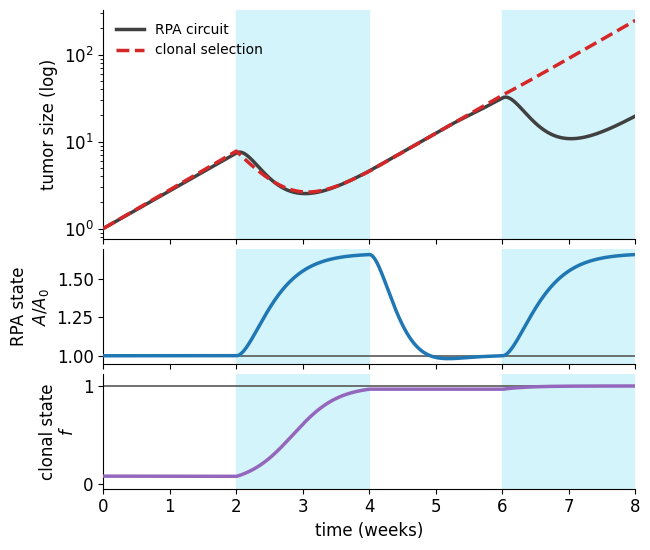

In [143]:
# --- Panel D: re-challenge after a drug holiday ---------------------------
on_blocks = [(2.0, 4.0), (6.0, 8.0)]
sched = lambda s: 1.0 if any(a <= s < b for a, b in on_blocks) else 0.0

t_rc = np.linspace(0, T, 3200)
A_rc, B_rc, C_rc = rpa_traj(t_rc, sched)         # RPA under the same schedule


Cs_rc, Cr_rc = clones(t_rc, sched,                # panel A's fitted parameters,
                      r_s=r_s_fit, r_r=r_r_fit,   # so both arms start from a
                      kappa=kappa_fit, f0=f0_fit)  # matched first course
tot_rc = Cs_rc + Cr_rc


def block_response(tt, y, a, b):
    """Fold-change from the start of an on-block to its lowest point."""
    m = (tt >= a) & (tt <= b)
    return y[m].min() / y[m][0]


fig, axes = plt.subplots(3, 1, figsize=(6.5, 5.6), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 1]})
for ax in axes:
    ax.set_xlim(0, T)
    ax.set_xticks(range(int(T) + 1))
    ax.tick_params(labelsize=FS)
    ax.spines[['top', 'right']].set_visible(False)
    for a, b in on_blocks:
        ax.axvspan(a, b, color=DRUG_SHADE, zorder=0)

axes[0].plot(t_rc, C_rc / C_rc[0], color='0.25', lw=2.5, zorder=3,
             label='RPA circuit')
axes[0].plot(t_rc, tot_rc / tot_rc[0], color='tab:red', lw=2.5, ls='--', zorder=3,
             label='clonal selection')
axes[0].set_yscale('log')
axes[0].set_ylabel('tumor size (log)', fontsize=FS)
axes[0].legend(fontsize=FS - 2, frameon=False, loc='upper left')

axes[1].plot(t_rc, A_rc / A_rc[0], color='tab:blue', lw=2.5, zorder=3)
axes[1].axhline(1, color='0.35', lw=1.2, zorder=1)
axes[1].set_ylabel('RPA state\n$A/A_0$', fontsize=FS)

axes[2].plot(t_rc, Cr_rc / tot_rc, color='tab:purple', lw=2.5, zorder=3)
axes[2].axhline(1, color='0.35', lw=1.2, zorder=1)
axes[2].set_ylim(-0.05, 1.12)
axes[2].set_yticks([0, 1])
axes[2].set_ylabel('clonal state\n$f$', fontsize=FS)
axes[2].set_xlabel('time (weeks)', fontsize=FS)

fig.tight_layout(h_pad=0.4)
save_fig(fig, "figure_rechallenge")

for name, y in [('RPA circuit    ', C_rc), ('clonal selection', tot_rc)]:
    d1 = block_response(t_rc, y, *on_blocks[0])
    d2 = block_response(t_rc, y, *on_blocks[1])
    print(f'{name}: response in course 1 = {d1:.3f}x, in course 2 = {d2:.3f}x '
          f'(ratio {d2 / d1:.2f})')